# m10a — Siamese Calibration Branch (V1)

**Goal:** Add a calibration branch to GazeNetM5 that conditions predictions on a subject's "neutral" face image.

**Steps:**
1. Select one calibration frame per subject (Straight frame closest to (0,0) PoG)
2. Build calibration bank: `{subject_id: face_crop_tensor}` → saved as `.pt`
3. WebDataset wrapper to inject calibration image per sample
4. GazeNetM10 architecture (m5c + cal_cnn branch)
5. Training loop

**Key decisions:**
- cal_cnn is independent (no weight sharing with face_cnn)
- Calibration image is NOT augmented during training
- CEAL eval uses 0V_0H images as calibration

In [26]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from collections import defaultdict
import torch.nn as nn

In [2]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Google Drive root
DRIVE_ROOT = Path("/content/drive/MyDrive/210/")

# Labels CSV — has subject_id, frame_key, PoG coords, 5-class label
LABELS_CSV = DRIVE_ROOT / "gaze_labels.csv"

# Where to save the calibration bank
CAL_BANK_OUT = DRIVE_ROOT / "calibration_bank_v1.pt"

## Step 1: Select calibration frames

For each subject:
- Filter to Straight-labeled frames
- Pick the frame with smallest Euclidean distance from (0,0) in PoG space
- For subjects without any Straight frames (~3), pick the frame with smallest overall gaze angle

In [4]:
df = pd.read_csv(LABELS_CSV)
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Unique subjects: {df['subject_id'].nunique()}")
df.head()

Total rows: 849,131
Columns: ['subject_id', 'frame_idx', 'pog_x', 'pog_y', 'label']
Unique subjects: 640


,subject_id,frame_idx,pog_x,pog_y,label
0,2,0,1.064000,-6.005500,Down
1,2,1,1.064000,-6.005500,Down
2,2,2,1.064000,-6.005500,Down
3,2,3,1.064000,-6.005500,Down
4,2,4,3.251485,-1.993073,Straight


In [5]:
COL_SUBJECT = "subject_id"
COL_FRAME   = "frame_idx"
COL_POG_X   = "pog_x"
COL_POG_Y   = "pog_y"
COL_LABEL   = "label"

In [6]:
# Distance from (0,0) PoG for every frame
df["pog_dist"] = np.sqrt(df[COL_POG_X]**2 + df[COL_POG_Y]**2)

# --- Subjects WITH Straight frames ---
straight = df[df[COL_LABEL] == "Straight"].copy()
cal_straight = (
    straight
    .sort_values("pog_dist")
    .groupby(COL_SUBJECT)
    .first()
    .reset_index()
)

# --- Subjects WITHOUT Straight frames (fallback: smallest gaze angle) ---
subjects_with_straight = set(cal_straight[COL_SUBJECT])
missing = df[~df[COL_SUBJECT].isin(subjects_with_straight)].copy()
cal_fallback = (
    missing
    .sort_values("pog_dist")
    .groupby(COL_SUBJECT)
    .first()
    .reset_index()
)

# Combine
cal_frames = pd.concat([cal_straight, cal_fallback], ignore_index=True)

print(f"Subjects with Straight cal frame: {len(cal_straight)}")
print(f"Subjects using fallback:          {len(cal_fallback)}")
print(f"Total calibration frames:         {len(cal_frames)}")

# Sanity: should match total unique subjects
assert cal_frames[COL_SUBJECT].nunique() == df[COL_SUBJECT].nunique(), "Subject count mismatch!"

Subjects with Straight cal frame: 637
Subjects using fallback:          3
Total calibration frames:         640


In [7]:
# Quick look at the distribution of PoG distances for selected cal frames
print(cal_frames["pog_dist"].describe())

# Peek at fallback subjects if any
if len(cal_fallback) > 0:
    print("\nFallback subjects:")
    print(cal_fallback[[COL_SUBJECT, COL_POG_X, COL_POG_Y, "pog_dist", COL_LABEL]])

count    640.000000
mean       1.793794
std        0.380724
min        1.437837
25%        1.700549
50%        1.701549
75%        1.780500
max        6.131574
Name: pog_dist, dtype: float64

Fallback subjects:
   subject_id     pog_x     pog_y  pog_dist  label
0         317  4.748862  3.291607  5.778094  Right
1         825 -1.499688 -5.428229  5.631584   Down
2        1087 -1.237000 -6.005500  6.131574   Down


## Step 2: Extract face crops from tars

Next: read the selected calibration frames from WebDataset tars, extract face crops, resize to 224×224, and save as the calibration bank `.pt` file.

only needs to run once

In [21]:
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.2 MB/s eta 0:00:00


In [22]:
# --- Step 2a: Imports for tar extraction ---
import webdataset as wds
from PIL import Image
import torchvision.transforms as transforms
import io
import glob
import os

In [37]:
# --- Step 2b: Copy tars + discover files ---

TAR_DIR = "/content/gaze_wds_balanced"

# Copy from Drive (same as your training notebooks)
for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files_src = sorted(glob.glob(source + '*.tar'))
    for f in tar_files_src:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

# # We only need train+val tars for building the cal bank
# # (calibration subjects must cover all splits)
# all_tars = sorted(
#     glob.glob(f"{TAR_DIR}/train/*.tar") +
#     glob.glob(f"{TAR_DIR}/val/*.tar") +
#     glob.glob(f"{TAR_DIR}/test/*.tar")
# )
# print(f"\nTotal tar files: {len(all_tars)}")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [11]:
# # --- Step 2c: Peek at one tar sample to discover key format ---

# dataset = wds.WebDataset(all_tars[0]).decode("pil")
# sample = next(iter(dataset))

# print("Sample keys:", list(sample.keys()))
# print("__key__:", sample["__key__"])

# for k, v in sample.items():
#     if isinstance(v, Image.Image):
#         print(f"  {k}: PIL {v.size} {v.mode}")
#     elif isinstance(v, bytes):
#         print(f"  {k}: bytes len={len(v)}")
#     else:
#         print(f"  {k}: {type(v).__name__} = {str(v)[:100]}")

In [12]:
# # --- Step 2d: Build lookup set of calibration frame keys ---

# # Match tar __key__ format: "00003_000000" = {subject_id:05d}_{frame_idx:06d}
# cal_frames["tar_key"] = cal_frames.apply(
#     lambda r: f"{int(r['subject_id']):05d}_{int(r['frame_idx']):06d}", axis=1
# )
# cal_keys = set(cal_frames["tar_key"].values)
# print(f"Calibration keys to find: {len(cal_keys)}")
# print("Examples:", list(cal_keys)[:5])

In [13]:
# # --- Step 2e (revised): Scan tars for best available Straight frame per subject ---
# # Instead of looking for specific keys, scan all tars and track
# # the best Straight frame per subject (smallest pog_dist).

# import math

# # Load full labels to check Straight status + pog_dist
# df_labels = pd.read_csv(LABELS_CSV)
# df_labels["tar_key"] = df_labels.apply(
#     lambda r: f"{int(r['subject_id']):05d}_{int(r['frame_idx']):06d}", axis=1
# )
# # Quick lookup: tar_key → (label, pog_dist)
# label_lookup = {}
# for _, r in df_labels.iterrows():
#     dist = math.sqrt(r["pog_x"]**2 + r["pog_y"]**2)
#     label_lookup[r["tar_key"]] = (r["label"], dist)

# # Track best candidate per subject: {subject_id: (pog_dist, PIL image)}
# best_cal = {}

# for i, tar_path in enumerate(all_tars):
#     ds = wds.WebDataset(tar_path, shardshuffle=False).decode("pil")
#     for sample in ds:
#         key = sample["__key__"]
#         sid = sample["json"]["subject_id"]

#         if key not in label_lookup:
#             continue
#         lbl, dist = label_lookup[key]

#         # Prefer Straight frames; fallback to any frame with smallest dist
#         is_straight = (lbl == "Straight")

#         if sid not in best_cal:
#             best_cal[sid] = (is_straight, dist, sample["face.jpg"])
#         else:
#             prev_straight, prev_dist, _ = best_cal[sid]
#             # Straight always beats non-Straight; within same category, smaller dist wins
#             if (is_straight and not prev_straight) or \
#                (is_straight == prev_straight and dist < prev_dist):
#                 best_cal[sid] = (is_straight, dist, sample["face.jpg"])

#     if (i + 1) % 10 == 0:
#         print(f"  scanned {i+1}/{len(all_tars)} tars, {len(best_cal)} subjects found")

# print(f"\nTotal subjects with cal frame: {len(best_cal)}")
# n_straight = sum(1 for s, d, _ in best_cal.values() if s)
# print(f"  from Straight: {n_straight}")
# print(f"  from fallback: {len(best_cal) - n_straight}")

In [14]:
# # --- Debug: what does cal_frames actually look like? ---
# print(cal_frames.columns.tolist())
# print(cal_frames.head())

In [15]:
# # --- Step 2f (revised): Convert to calibration bank ---

# resize_tf = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])

# cal_bank_pil = {}  # keep for visual check
# cal_bank = {}
# for sid, (is_straight, dist, pil_img) in best_cal.items():
#     cal_bank_pil[sid] = pil_img
#     cal_bank[sid] = resize_tf(pil_img)

# sample_sid = next(iter(cal_bank))
# sample_t = cal_bank[sample_sid]
# print(f"Subjects in bank: {len(cal_bank)}")
# print(f"Sample tensor: shape={sample_t.shape}, dtype={sample_t.dtype}, "
#       f"min={sample_t.min():.3f}, max={sample_t.max():.3f}")

In [16]:
# # --- Step 2g: Save calibration bank ---

# torch.save(cal_bank, str(CAL_BANK_OUT))
# print(f"Saved to {CAL_BANK_OUT}")
# print(f"File size: {CAL_BANK_OUT.stat().st_size / 1024 / 1024:.1f} MB")

In [18]:
# # --- Step 2h: Visual sanity check — show a few calibration faces ---

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# for ax, (sid, tensor) in zip(axes.flat, list(cal_bank.items())[:10]):
#     # CHW → HWC for display
#     ax.imshow(tensor.permute(1, 2, 0).numpy())
#     ax.set_title(f"subj {sid}")
#     ax.axis("off")
# plt.suptitle("Calibration bank samples (224x224)")
# plt.tight_layout()
# plt.show()

## Step 3

In [19]:
# --- Step 3: WebDataset wrapper to inject calibration image per sample ---
# Loads the cal bank into memory once, then attaches the matching
# calibration face tensor to every sample by subject_id lookup.

def make_cal_injector(cal_bank_path):
    """
    Returns a map function for WebDataset that adds 'cal_face' to each sample.
    Cal bank is loaded once and held in closure memory.
    """
    bank = torch.load(cal_bank_path, map_location="cpu", weights_only=True)
    print(f"Loaded cal bank: {len(bank)} subjects")

    def inject_cal(sample):
        sid = sample["json"]["subject_id"]
        if sid in bank:
            sample["cal_face"] = bank[sid]  # [3, 224, 224] tensor, no augmentation
        else:
            # Shouldn't happen — log and use zeros as fallback
            print(f"WARNING: no cal image for subject {sid}")
            sample["cal_face"] = torch.zeros(3, 224, 224)
        return sample

    return inject_cal

In [24]:
# # --- Step 3b: Quick test — verify injection works on one sample ---

# inject_cal = make_cal_injector(CAL_BANK_OUT)

# test_ds = (
#     wds.WebDataset(all_tars[0], shardshuffle=False)
#     .decode("pil")
#     .map(inject_cal)
# )

# test_sample = next(iter(test_ds))
# print(f"Subject: {test_sample['json']['subject_id']}")
# print(f"cal_face: shape={test_sample['cal_face'].shape}, "
#       f"dtype={test_sample['cal_face'].dtype}, "
#       f"min={test_sample['cal_face'].min():.3f}, "
#       f"max={test_sample['cal_face'].max():.3f}")
# print(f"face.jpg: {test_sample['face.jpg'].size}")  # still PIL at this stage

## Step 4: Build Model Architecture

In [27]:
# --- Step 4: CalCNN — calibration face encoder ---
# Small independent CNN: [B, 3, 224, 224] → [B, 128]

class CalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),   # → [32, 112, 112]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → [64, 56, 56]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # → [128, 28, 28]
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                # → [128, 1, 1]
        )
        self.fc = nn.Linear(128, 128)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [28]:
# --- Step 4b: GazeNetM10a — m5c + calibration branch ---
# FC input: 4608 + 4608 + 2304 + 64 + 128 = 11712 → 512 → 256 → 4

class GazeNetM10a(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super().__init__()

        # ---- Reuse same architecture as m5c ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- NEW: calibration branch ----
        self.cal_cnn = CalCNN()

        # ---- FC head: expanded input (+ 128 from cal) ----
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64 + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features, cal_face):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        cal_feat   = self.cal_cnn(cal_face)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat, cal_feat], dim=1)
        return self.fc(combined)

In [29]:
# --- Step 4c: Load m5c weights into GazeNetM10a backbone ---
# Copies eye_cnn, face_cnn, geo_mlp weights from trained m5c.
# FC is fresh (different input dim). cal_cnn trains from scratch.

# !!! UPDATE path to your m5c checkpoint
M5C_CKPT = DRIVE_ROOT / "m5c.pth"  # !!! confirm path

def load_m5c_into_m10a(m10a_model, ckpt_path):
    """Load m5c backbone weights into m10a, skip FC (shape mismatch)."""
    m5_state = torch.load(ckpt_path, map_location="cpu")

    loaded, skipped = [], []
    m10a_state = m10a_model.state_dict()

    for key, val in m5_state.items():
        if key in m10a_state and m10a_state[key].shape == val.shape:
            m10a_state[key] = val
            loaded.append(key)
        else:
            skipped.append(key)

    m10a_model.load_state_dict(m10a_state)
    print(f"Loaded {len(loaded)} params from m5c")
    print(f"Skipped {len(skipped)}: {skipped}")
    return m10a_model

model = GazeNetM10a(num_classes=4)
model = load_m5c_into_m10a(model, M5C_CKPT)

total_params = sum(p.numel() for p in model.parameters())
cal_params = sum(p.numel() for p in model.cal_cnn.parameters())
fc_params = sum(p.numel() for p in model.fc.parameters())
print(f"\nTotal params:  {total_params:,}")
print(f"CalCNN params: {cal_params:,}")
print(f"New FC params: {fc_params:,}")

Loaded 23 params from m5c
Skipped 1: ['fc.0.weight']

Total params:  6,763,652
CalCNN params: 111,296
New FC params: 6,129,412


In [30]:
# --- Step 4d: Smoke test — verify forward pass shapes ---
# Eyes are resized to 48x48 in the training pipeline (→ 4608 after CNN)
# Face stays 112x112 (→ 2304 after CNN)

dummy_left  = torch.randn(2, 3, 48, 48)
dummy_right = torch.randn(2, 3, 48, 48)
dummy_face  = torch.randn(2, 3, 112, 112)
dummy_geo   = torch.randn(2, 7)
dummy_cal   = torch.randn(2, 3, 224, 224)

model.eval()
with torch.no_grad():
    out = model(dummy_left, dummy_right, dummy_face, dummy_geo, dummy_cal)
print(f"Output shape: {out.shape}")  # expect [2, 4]

Output shape: torch.Size([2, 4])


## Train

In [31]:
# --- Step 5: Training config ---

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
NVIDIA A100-SXM4-80GB


In [32]:
# --- Step 5b: Load labels + geo features (same as m5c) ---

GEO_PARQUET = DRIVE_ROOT / "geo_features_v1.parquet"

# ---- Label lookup (4-class, drop Straight) ----
df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}

label_lookup_4 = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    if row['label'] != 'Straight':
        label_lookup_4[key] = row['label']

print(f"4-class label lookup: {len(label_lookup_4)} entries")

# ---- Geo features lookup ----
df_geo = pd.read_parquet(GEO_PARQUET)
geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['key']] = row[geo_cols].values.astype(np.float32)

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

print(f"Geo lookup: {len(geo_lookup)} entries")

4-class label lookup: 602467 entries
Geo lookup: 273462 entries


In [33]:
# --- Step 5c: Transforms (match m5c exactly) ---
# Cal face gets Normalize but NO augmentation.

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Cal face: already a [3, 224, 224] tensor in [0,1] from the bank.
# Just normalize to match the backbone's expected range.
cal_normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

print("Transforms defined")

Transforms defined


In [34]:
# --- Step 5d: Dataset pipeline with cal injection ---

def make_cal_injector(cal_bank_path):
    bank = torch.load(cal_bank_path, map_location="cpu")
    print(f"Loaded cal bank: {len(bank)} subjects")

    def inject(sample):
        sid = sample["json"]["subject_id"]
        if sid in bank:
            sample["cal_face"] = bank[sid]
        else:
            print(f"WARNING: no cal image for subject {sid}")
            sample["cal_face"] = torch.zeros(3, 224, 224)
        return sample

    return inject

cal_injector = make_cal_injector(CAL_BANK_OUT)

def make_dataset_m10a(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        # Skip Straight
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        # Cal face: normalize only, no augmentation
        cal_face = cal_normalize(sample["cal_face"])

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'cal_face': cal_face,
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(cal_injector)
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_m10a defined")

Loaded cal bank: 640 subjects
make_dataset_m10a defined


In [39]:
import math

In [40]:
# --- Step 5e: Loaders + model + optimizer (match m5c hyperparams) ---

train_tars = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tars   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tars  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

train_dataset = make_dataset_m10a(train_tars, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_m10a(val_tars,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_m10a(test_tars,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

# ---- Model ----
model = GazeNetM10a(num_classes=4).to(DEVICE)
model = load_m5c_into_m10a(model, DRIVE_ROOT / "m5c.pth")

# ---- Class weights (sqrt inv freq, same as m5c) ----
train_counts = [4247, 51514, 42872, 40888]  # Up, Down, Left, Right
total = sum(train_counts)
weights = [math.sqrt(total / (4 * c)) for c in train_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print("Class weights:")
for name, w in zip(['Up', 'Down', 'Left', 'Right'], weights):
    print(f"  {name:6s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded 23 params from m5c
Skipped 1: ['fc.0.weight']
Class weights:
  Up    : 2.866
  Down  : 0.823
  Left  : 0.902
  Right : 0.924

Parameters: 6,763,652


In [41]:
# --- Step 5f: Smoke test ---

test_tar = [train_tars[0]]
test_ds = make_dataset_m10a(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))
print(f"left_eye:     {batch['left_eye'].shape}")
print(f"right_eye:    {batch['right_eye'].shape}")
print(f"face:         {batch['face'].shape}")
print(f"geo_features: {batch['geo_features'].shape}")
print(f"cal_face:     {batch['cal_face'].shape}")
print(f"label:        {batch['label'].tolist()}")

model.eval()
with torch.no_grad():
    out = model(
        batch['left_eye'].to(DEVICE),
        batch['right_eye'].to(DEVICE),
        batch['face'].to(DEVICE),
        batch['geo_features'].to(DEVICE),
        batch['cal_face'].to(DEVICE),
    )
print(f"Output: {out.shape}  <-- should be [4, 4]")

left_eye:     torch.Size([4, 3, 48, 48])
right_eye:    torch.Size([4, 3, 48, 48])
face:         torch.Size([4, 3, 112, 112])
geo_features: torch.Size([4, 7])
cal_face:     torch.Size([4, 3, 224, 224])
label:        [1, 1, 1, 1]
Output: torch.Size([4, 4])  <-- should be [4, 4]


In [43]:
import time

In [44]:
# --- Step 5g: Training loop ---
# train end-to-end (like m5c)

num_epochs = 20
best_val_loss = float('inf')
patience = 6
patience_counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

CKPT_DIR = DRIVE_ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ---- TRAIN ----
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(DEVICE)
        right_eye    = batch['right_eye'].to(DEVICE)
        face         = batch['face'].to(DEVICE)
        geo_features = batch['geo_features'].to(DEVICE)
        cal_face     = batch['cal_face'].to(DEVICE)
        labels       = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features, cal_face)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta_min = (elapsed / (batch_idx + 1)) * (7000 - batch_idx - 1) / 60
            print(f"  Batch {batch_idx+1}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_min:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total

    # ---- VAL ----
    model.eval()
    val_loss, val_correct, val_total, val_batch_count = 0.0, 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(DEVICE)
            right_eye    = batch['right_eye'].to(DEVICE)
            face         = batch['face'].to(DEVICE)
            geo_features = batch['geo_features'].to(DEVICE)
            cal_face     = batch['cal_face'].to(DEVICE)
            labels       = batch['label'].to(DEVICE)

            outputs = model(left_eye, right_eye, face, geo_features, cal_face)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - epoch_start

    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"  Train loss: {avg_train_loss:.4f}  acc: {train_acc:.2f}%")
    print(f"  Val   loss: {avg_val_loss:.4f}  acc: {val_acc:.2f}%  ({epoch_time:.0f}s)")

    # ---- Early stopping + checkpoint ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), str(CKPT_DIR / "m10a_best.pth"))
        print(f"  -> New best val loss: {avg_val_loss:.4f}, saved.")
    else:
        patience_counter += 1
        print(f"  -> No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

torch.save(model.state_dict(), str(CKPT_DIR / "m10a_final.pth"))
print(f"\nDone. Best val loss: {best_val_loss:.4f}")


Epoch 1/20
  Batch 1000/~7000 - Loss: 0.6089 - ETA: 15.7 min
  Batch 2000/~7000 - Loss: 0.6396 - ETA: 13.2 min
  Batch 3000/~7000 - Loss: 0.5728 - ETA: 10.3 min
  Batch 4000/~7000 - Loss: 0.6388 - ETA: 7.6 min
  Train loss: 0.5968  acc: 95.61%
  Val   loss: 0.6793  acc: 91.24%  (738s)
  -> New best val loss: 0.6793, saved.

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.5904 - ETA: 15.8 min
  Batch 2000/~7000 - Loss: 0.6441 - ETA: 13.2 min
  Batch 3000/~7000 - Loss: 0.5642 - ETA: 10.3 min
  Batch 4000/~7000 - Loss: 0.5114 - ETA: 7.6 min
  Train loss: 0.5645  acc: 96.97%
  Val   loss: 0.6669  acc: 91.71%  (739s)
  -> New best val loss: 0.6669, saved.

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.5289 - ETA: 15.7 min
  Batch 2000/~7000 - Loss: 0.5768 - ETA: 13.1 min
  Batch 3000/~7000 - Loss: 0.5793 - ETA: 10.2 min
  Batch 4000/~7000 - Loss: 0.5112 - ETA: 7.5 min
  Train loss: 0.5547  acc: 97.31%
  Val   loss: 0.6640  acc: 91.96%  (737s)
  -> New best val loss: 0.6640, saved.

Epoch 4/20
  Batch 10

In [45]:
# --- Diagnostic: cal_cnn embedding magnitude vs other branches ---

model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    left_feat  = model.eye_cnn(batch['left_eye'].to(DEVICE)).view(batch['left_eye'].size(0), -1)
    right_feat = model.eye_cnn(batch['right_eye'].to(DEVICE)).view(batch['right_eye'].size(0), -1)
    face_feat  = model.face_cnn(batch['face'].to(DEVICE)).view(batch['face'].size(0), -1)
    geo_feat   = model.geo_mlp(batch['geo_features'].to(DEVICE))
    cal_feat   = model.cal_cnn(batch['cal_face'].to(DEVICE))

print(f"left_eye  mean abs: {left_feat.abs().mean():.4f}")
print(f"right_eye mean abs: {right_feat.abs().mean():.4f}")
print(f"face      mean abs: {face_feat.abs().mean():.4f}")
print(f"geo       mean abs: {geo_feat.abs().mean():.4f}")
print(f"cal_cnn   mean abs: {cal_feat.abs().mean():.4f}")

left_eye  mean abs: 0.0079
right_eye mean abs: 0.0085
face      mean abs: 0.0311
geo       mean abs: 0.0140
cal_cnn   mean abs: 0.0002


In [47]:
MODEL_NAME='m10a'

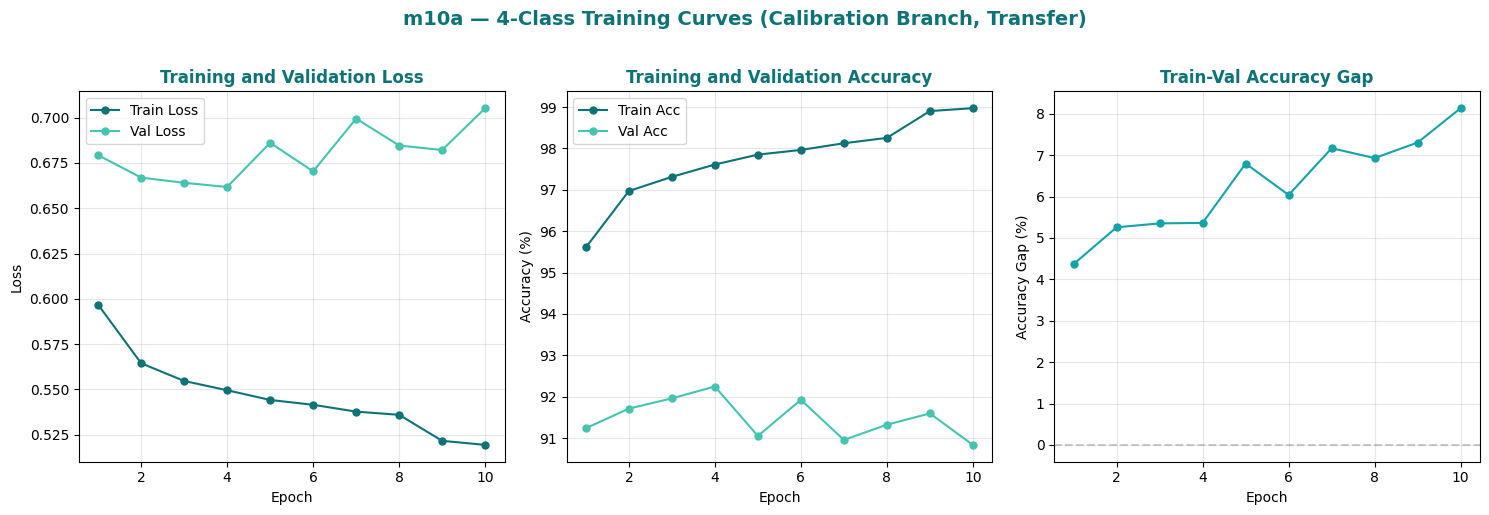


Training Summary
Total epochs completed: 10
Best validation loss: 0.6617 (Epoch 4)
Best validation accuracy: 92.25% (Epoch 4)


In [49]:
# ============================================================
# LOSS CURVES — Teal theme (matches m5c)
# ============================================================

MODEL_NAME = 'm10a'

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Calibration Branch, Transfer)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")

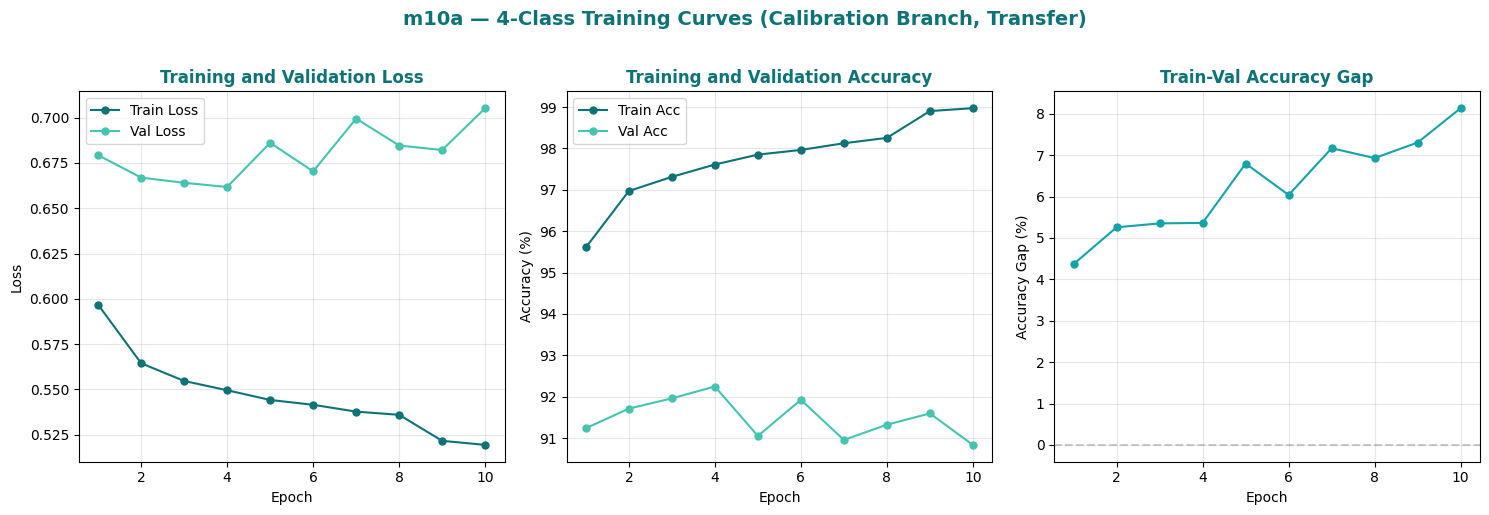


Training Summary
Total epochs completed: 10
Best validation loss: 0.6617 (Epoch 4)
Best validation accuracy: 92.25% (Epoch 4)
Final train accuracy: 98.97%
Final val accuracy: 90.84%
Final train-val gap: 8.14%


In [50]:
# ============================================================
# LOSS CURVES — Teal theme
# ============================================================

MODEL_NAME = 'm10a'

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Calibration Branch, Transfer)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)

In [52]:
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

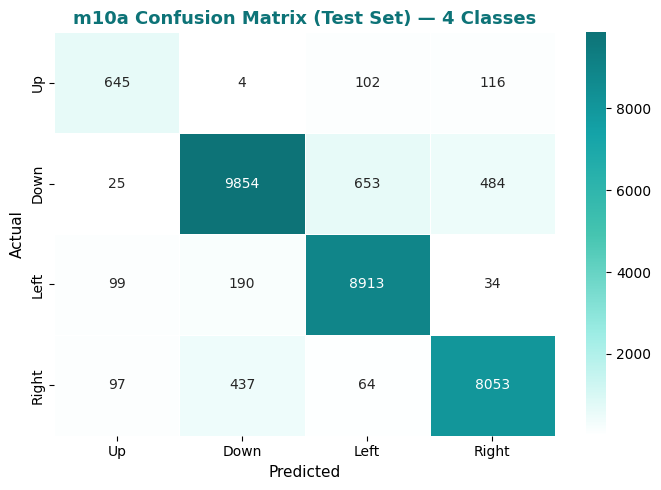


m10a Test Set Performance
              precision    recall  f1-score   support

          Up       0.74      0.74      0.74       867
        Down       0.94      0.89      0.92     11016
        Left       0.92      0.97      0.94      9236
       Right       0.93      0.93      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.88      0.88      0.88     29770
weighted avg       0.92      0.92      0.92     29770



In [53]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX — 4 classes, teal theme
# ============================================================

CHECKPOINT_PATH = str(CKPT_DIR / 'm10a_best.pth')

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(DEVICE)
        right_eye    = batch['right_eye'].to(DEVICE)
        face         = batch['face'].to(DEVICE)
        geo_features = batch['geo_features'].to(DEVICE)
        cal_face     = batch['cal_face'].to(DEVICE)
        labels       = batch['label'].to(DEVICE)

        outputs = model(left_eye, right_eye, face, geo_features, cal_face)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- 4-class labels ----
label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

# ---- Teal colormap ----
teal_cmap = LinearSegmentedColormap.from_list('teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

In [54]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINT
# ============================================================

print(f"train_losses_{MODEL_NAME} =", train_losses)
print(f"val_losses_{MODEL_NAME} =", val_losses)
print(f"train_acc_{MODEL_NAME} =", train_accuracies)
print(f"val_acc_{MODEL_NAME} =", val_accuracies)

print(f"\nCheckpoint exists: {os.path.exists(CHECKPOINT_PATH)}")
print(f"Size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB")

train_losses_m10a = [0.5967730145557187, 0.5644707844238767, 0.554700308725173, 0.5495802186697728, 0.5442178661438938, 0.5415567368972851, 0.5377831525743568, 0.5360195495357374, 0.5216707316827567, 0.5194318605259289]
val_losses_m10a = [0.6792692237991398, 0.6668925494460737, 0.6640255322900869, 0.6617191399894865, 0.6860962034618787, 0.6703337310397692, 0.6994470614497944, 0.6846080337877327, 0.6821129482344719, 0.7052052397512447]
train_acc_m10a = [95.60782964571642, 96.9703485496807, 97.31223256714043, 97.61039556769232, 97.84978605371235, 97.9630306548835, 98.12429670085507, 98.25402627561442, 98.90195741142911, 98.9721977336745]
val_acc_m10a = [91.23824340569973, 91.71204299554486, 91.95955024397144, 92.24595148857931, 91.05084506046248, 91.92419206562478, 90.95537797892652, 91.3231030337317, 91.59536100700092, 90.83516017254792]

Checkpoint exists: True
Size: 27.1 MB


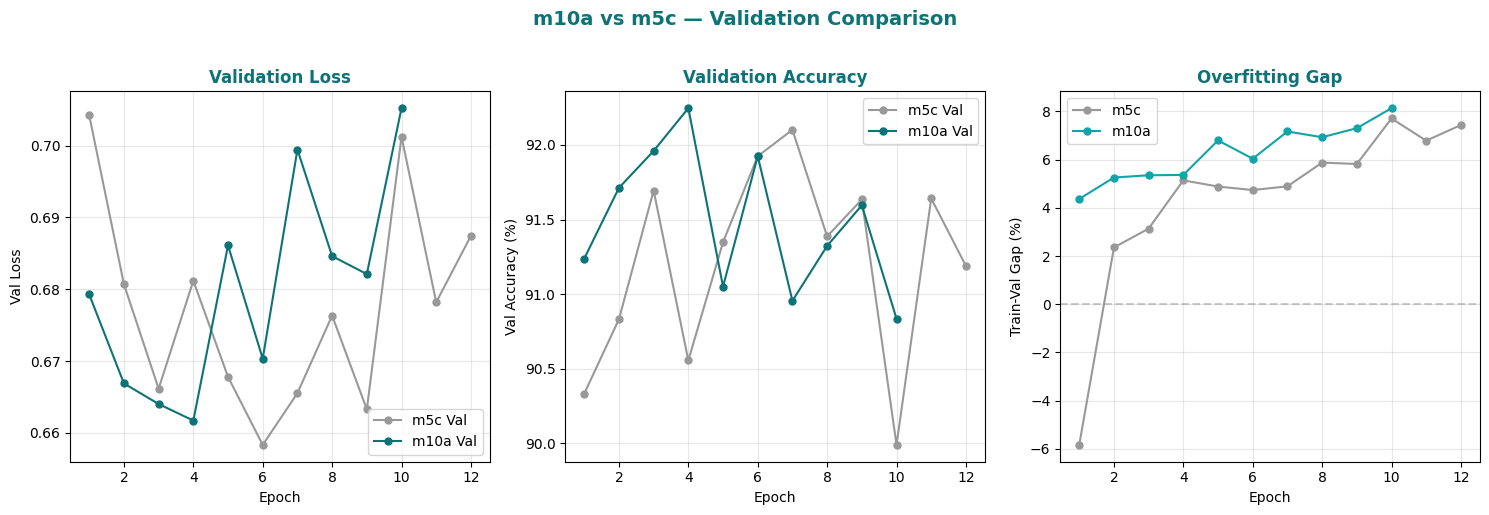


m10a vs m5c
m5c  best val loss: 0.6583  best val acc: 92.10%
m10a best val loss: 0.6617  best val acc: 92.25%
Delta val loss:  +0.0034  (negative = m10a better)
Delta val acc:   +0.14%  (positive = m10a better)


In [55]:
# ============================================================
# COMPARE m10a vs m5c
# ============================================================

# m5c results (from training run)
m5c_train_losses = [0.8119657339100662, 0.6533410661511945, 0.6146887101402143, 0.5943828028253229, 0.5817236840260245, 0.5719863340631042, 0.5644072491117804, 0.5586943424259186, 0.553295024031484, 0.5484996645159744, 0.5326650714866067, 0.5283544815357495]
m5c_val_losses = [0.7042028013595754, 0.6806879599047246, 0.6661611421296826, 0.6811815809563728, 0.6677970519173617, 0.6583361093270577, 0.6655390130597992, 0.6763349390636056, 0.6632756286590112, 0.7012312029041139, 0.6781952198952604, 0.6874267592605224]
m5c_train_acc = [84.49552397130181, 93.18740548017861, 94.83231914908866, 95.69598841751422, 96.23282516610402, 96.66215121737946, 96.99400090308986, 97.2649278603221, 97.45486342557751, 97.6992710774722, 98.42962708122792, 98.62601328832218]
m5c_val_acc = [90.33307404002545, 90.83162435471324, 91.69436390637155, 90.55583056360936, 91.34785375857436, 91.92419206562478, 92.10098295735804, 91.38674775475567, 91.63425500318223, 89.99009971006294, 91.64132663885157, 91.18874195601443]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss comparison ----
ax = axes[0]
ax.plot(range(1, len(m5c_val_losses) + 1), m5c_val_losses, '-o', color='#999999', label='m5c Val', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_dark, label='m10a Val', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_title('Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy comparison ----
ax = axes[1]
ax.plot(range(1, len(m5c_val_acc) + 1), m5c_val_acc, '-o', color='#999999', label='m5c Val', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_dark, label='m10a Val', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy (%)')
ax.set_title('Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap comparison ----
ax = axes[2]
m5c_gap = [m5c_train_acc[i] - m5c_val_acc[i] for i in range(len(m5c_train_acc))]
m10a_gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(m5c_gap) + 1), m5c_gap, '-o', color='#999999', label='m5c', markersize=5)
ax.plot(range(1, len(m10a_gap) + 1), m10a_gap, '-o', color=teal_mid, label='m10a', markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train-Val Gap (%)')
ax.set_title('Overfitting Gap', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('m10a vs m5c — Validation Comparison',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Delta summary ----
print("\n" + "="*50)
print("m10a vs m5c")
print("="*50)
print(f"m5c  best val loss: {min(m5c_val_losses):.4f}  best val acc: {max(m5c_val_acc):.2f}%")
print(f"m10a best val loss: {min(val_losses):.4f}  best val acc: {max(val_accuracies):.2f}%")
print(f"Delta val loss:  {min(val_losses) - min(m5c_val_losses):+.4f}  (negative = m10a better)")
print(f"Delta val acc:   {max(val_accuracies) - max(m5c_val_acc):+.2f}%  (positive = m10a better)")
print("="*50)